In [198]:
# Import Libraries

In [199]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt 
import numpy as np

In [200]:
# Load the dataset

In [201]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [202]:
# Explore the dataset

Training Data Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Data Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)
Unique Labels: [0 1 2 3 4 5 6 7 8 9]


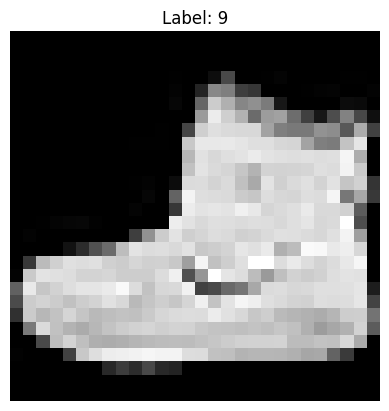

In [203]:
print("Training Data Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Data Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

print("Unique Labels:", np.unique(y_train))

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [204]:
#Normalize the Pixel Values

In [205]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [206]:
#Build the ANN

In [207]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [208]:
#Compile the Model

In [209]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [210]:
#Train the Model

In [211]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8178 - loss: 0.5207 - val_accuracy: 0.8477 - val_loss: 0.4219
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8595 - loss: 0.3918 - val_accuracy: 0.8670 - val_loss: 0.3677
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8727 - loss: 0.3520 - val_accuracy: 0.8512 - val_loss: 0.3990
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8809 - loss: 0.3235 - val_accuracy: 0.8732 - val_loss: 0.3562
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8876 - loss: 0.3054 - val_accuracy: 0.8750 - val_loss: 0.3410
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8943 - loss: 0.2854 - val_accuracy: 0.8724 - val_loss: 0.3480
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8991 - loss: 0.2720 - val_accuracy: 0.8685 - val_loss: 0.3717
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9009 - loss: 0.

In [212]:
# Evaluate the Model

In [213]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8770 - loss: 0.3474
Test Accuracy: 0.8769999742507935


In [214]:
#Display Training and Validation Accuracy

In [215]:
print("Training Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])

Training Accuracy: 0.9104583263397217
Validation Accuracy: 0.8828333616256714


In [216]:
#Make Predictions

In [217]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

for i in range(5):
    print(f"Image {i+1}")
    print("Predicted Label:", predicted_labels[i])
    print("Actual Label:", y_test[i])
    print()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Image 1
Predicted Label: 9
Actual Label: 9

Image 2
Predicted Label: 2
Actual Label: 2

Image 3
Predicted Label: 1
Actual Label: 1

Image 4
Predicted Label: 1
Actual Label: 1

Image 5
Predicted Label: 6
Actual Label: 6



In [218]:
#Bonus

In [219]:
# Plot Accuracy Curves

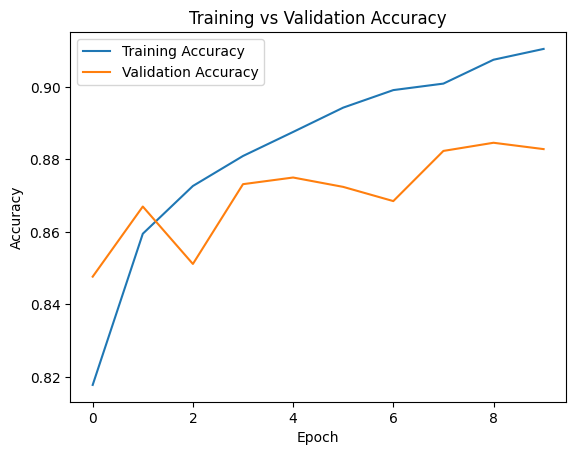

In [220]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [221]:
# Display Sample Predictions

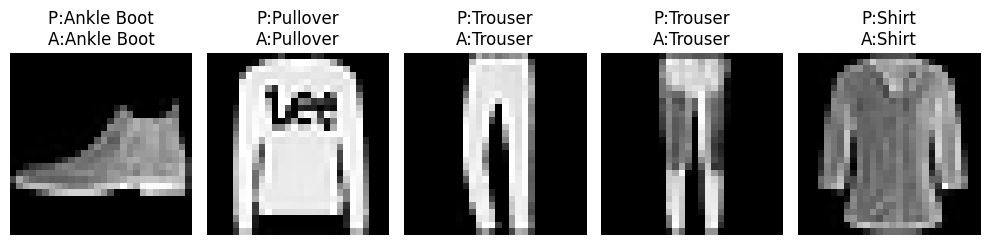

In [222]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"P:{class_names[predicted_labels[i]]}\nA:{class_names[y_test[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()